In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('german_credit_data.csv')

In [3]:
df.shape

(1000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
(df.isnull().sum()/len(df))*100

,0
Unnamed: 0,0.0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0


In [6]:
df['Checking account']=df['Checking account'].fillna(df['Checking account'].mode()[0])
df['Saving accounts']=df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   1000 non-null   object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [12]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 50, 60, 80],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)
Age_Risk=df.groupby('Age Group')['Risk'].value_counts(normalize=True).rename("Percentage").mul(100).reset_index()

/tmp/ipykernel_1296/1619569034.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Age_Risk=df.groupby('Age Group')['Risk'].value_counts(normalize=True).rename("Percentage").mul(100).reset_index()


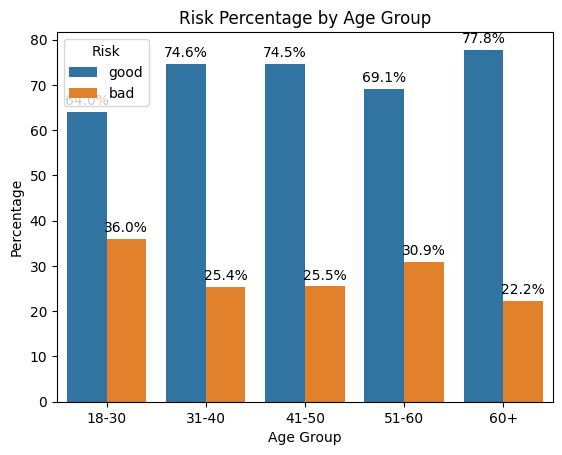

In [18]:
ax = sns.barplot(
    x='Age Group',
    y='Percentage',
    hue='Risk',
    data=Age_Risk
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.title('Risk Percentage by Age Group')
plt.show()

/tmp/ipykernel_1296/2946001609.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age Group', 'Risk'])['Duration']


Text(0.5, 1.0, 'Average Duration by Age Group and Risk')

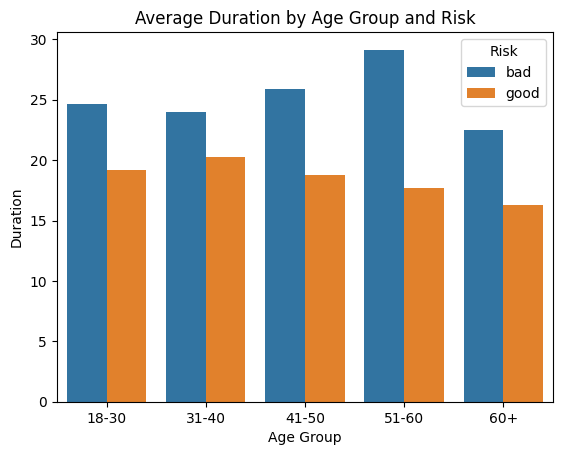

In [19]:
duration_age = (
    df.groupby(['Age Group', 'Risk'])['Duration']
      .mean()
      .reset_index()
)
sns.barplot(
    data=duration_age,
    x='Age Group',
    y='Duration',
    hue='Risk'
)
plt.xlabel('Age Group')
plt.ylabel('Duration')
plt.title('Average Duration by Age Group and Risk')

/tmp/ipykernel_1296/2961018626.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age Group', 'Risk'])['Credit amount']


Text(0.5, 1.0, 'Average Credit amount by Age Group and Risk')

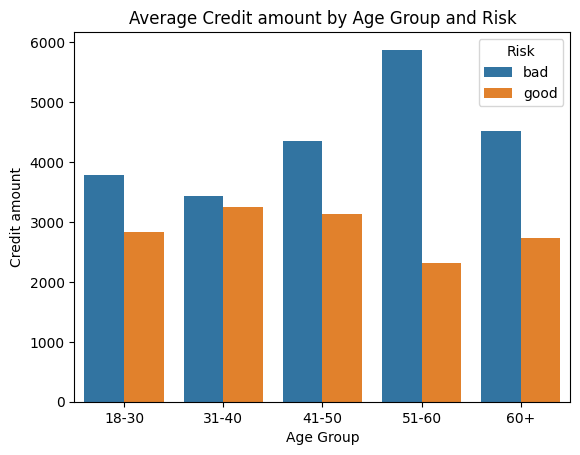

In [21]:
amount_age = (
    df.groupby(['Age Group', 'Risk'])['Credit amount']
      .mean()
      .reset_index()
)
sns.barplot(
    data=amount_age,
    x='Age Group',
    y='Credit amount',
    hue='Risk'
)
plt.xlabel('Age Group')
plt.ylabel('Credit amount')
plt.title('Average Credit amount by Age Group and Risk')
#

## 📌 Observation

It is observed that customers aged **18–30** have the **highest percentage of bad credit risk** among all age groups. To understand this pattern, the average loan duration and average credit amount were analyzed across different age groups.

The analysis shows that customers in the **18–30** age group who are classified as **bad credit risk** have an average loan duration of approximately **25 months** and an average credit amount of around **3,800**. Although these values are higher than those of good-risk customers in the same age group, they are **not the highest** among all age groups. Customers aged **51–60** exhibit both the highest average loan duration (approximately **29 months**) and the highest average credit amount (approximately **5,900**) among bad-risk customers.

---

## 💼 Business Insight

The higher bad credit risk observed in the **18–30** age group **cannot be explained solely by larger loan amounts or longer loan durations**. Since older age groups receive larger loans with longer repayment periods but still do not exhibit the highest bad credit risk percentage, other factors—such as employment stability, savings, checking account status, or financial history—may play a more significant role in determining credit risk for younger customers.

---

## ✅ Recommendation

Financial institutions should avoid relying only on **loan amount** and **loan duration** when evaluating younger applicants. Instead, they should incorporate additional indicators such as **income stability, employment history, savings behavior, checking account status, and previous credit history** to perform a more comprehensive credit risk assessment for customers aged **18–30**.

In [22]:
df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Age Group
0,67,male,2,own,little,little,1169,6,radio/TV,good,60+
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,18-30
2,49,male,1,own,little,little,2096,12,education,good,41-50
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,41-50
4,53,male,2,free,little,little,4870,24,car,bad,51-60


In [23]:
df['Checking account'].unique()

array(['little', 'moderate', 'rich'], dtype=object)

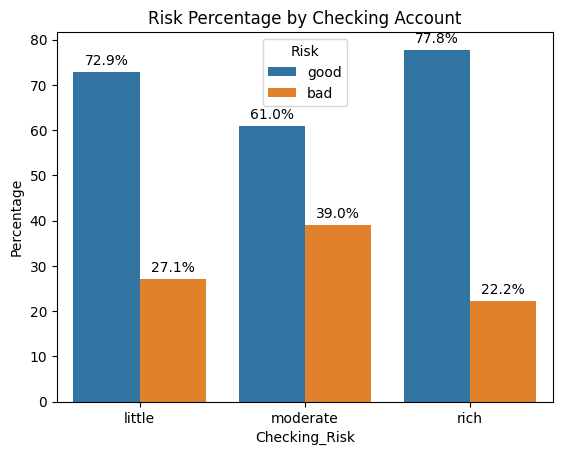

In [25]:
Checking_Risk=df.groupby('Checking account')['Risk'].value_counts(normalize=True).rename("Percentage").mul(100).reset_index()
ax = sns.barplot(
    x='Checking account',
    y='Percentage',
    hue='Risk',
    data=Checking_Risk
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlabel('Checking_Risk')
plt.ylabel('Percentage')
plt.title('Risk Percentage by Checking Account')
plt.show()

## 📌 Observation

It is observed that customers with **moderate checking account balances** have the highest percentage of **bad credit risk (39.0%)**, while customers with **rich checking account balances** have the lowest bad credit risk (22.2%).

---

## 💼 Business Insight

The analysis indicates that customers with stronger checking account balances are generally associated with lower credit risk. However, the higher bad credit risk observed among customers with moderate checking account balances cannot be fully explained using the current analysis alone and may be influenced by additional financial or demographic factors.

---

## ✅ Recommendation

Banks should perform additional credit assessments for applicants with moderate checking account balances by considering factors such as employment status, repayment history, loan amount, savings, and income before making lending decisions.

In [26]:
checking_job = (
    pd.crosstab(
        [df['Checking account'], df['Job']],
        df['Risk'],
        normalize='index'
    ) * 100
)

checking_job = (
    checking_job
    .reset_index()
    .melt(
        id_vars=['Checking account', 'Job'],
        var_name='Risk',
        value_name='Percentage'
    )
)

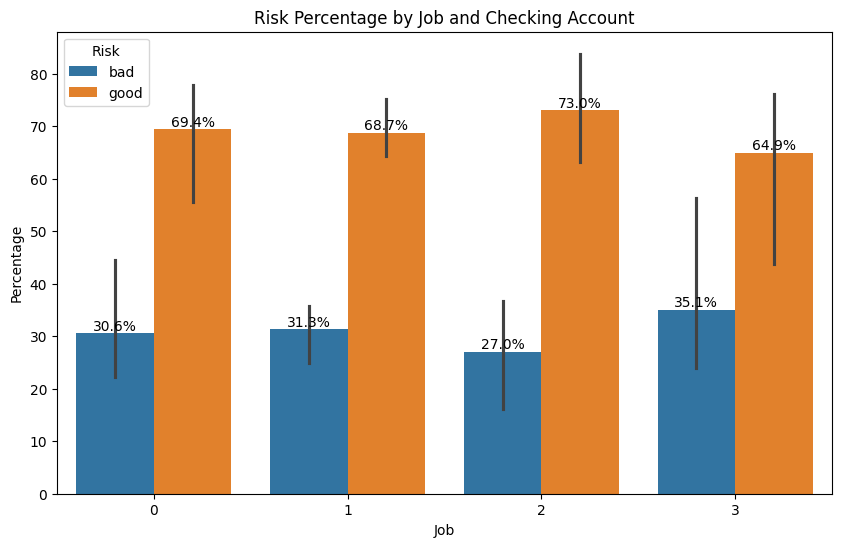

In [27]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=checking_job,
    x='Job',
    y='Percentage',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Risk Percentage by Job and Checking Account')
plt.show()


## 📌 Observation

It is observed that customers in **Job Category 3** have the highest percentage of **bad credit risk (35.1%)**, whereas customers in **Job Category 2** have the lowest bad credit risk (27.0%). Job Categories 0 and 1 exhibit similar levels of bad credit risk, around 31%.

---

## 💼 Business Insight

The analysis suggests that job category alone is **not a strong predictor of credit risk**, as the differences in bad credit risk across job categories are relatively moderate. While Job Category 3 shows the highest proportion of bad credit risk, employment category should be evaluated alongside other financial factors when assessing customer creditworthiness.

---

## ✅ Recommendation

Banks should avoid relying solely on job category when evaluating loan applications. A more comprehensive credit assessment should combine employment information with factors such as checking account status, savings, loan amount, repayment duration, and previous credit history.

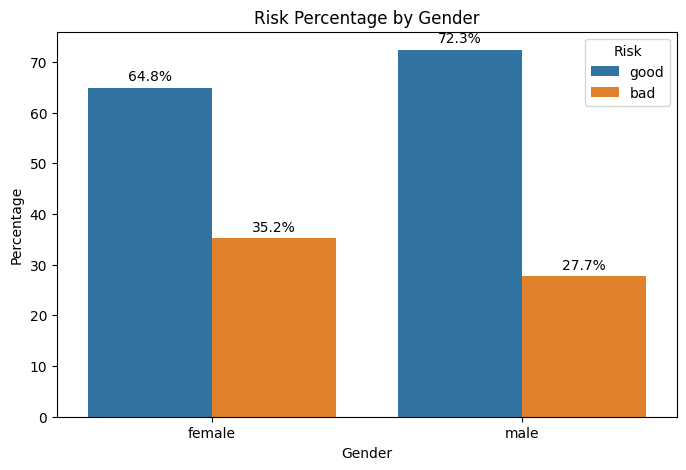

In [30]:
Sex_Risk = (
    df.groupby('Sex')['Risk']
      .value_counts(normalize=True)
      .rename("Percentage")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=Sex_Risk,
    x='Sex',
    y='Percentage',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Risk Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.show()

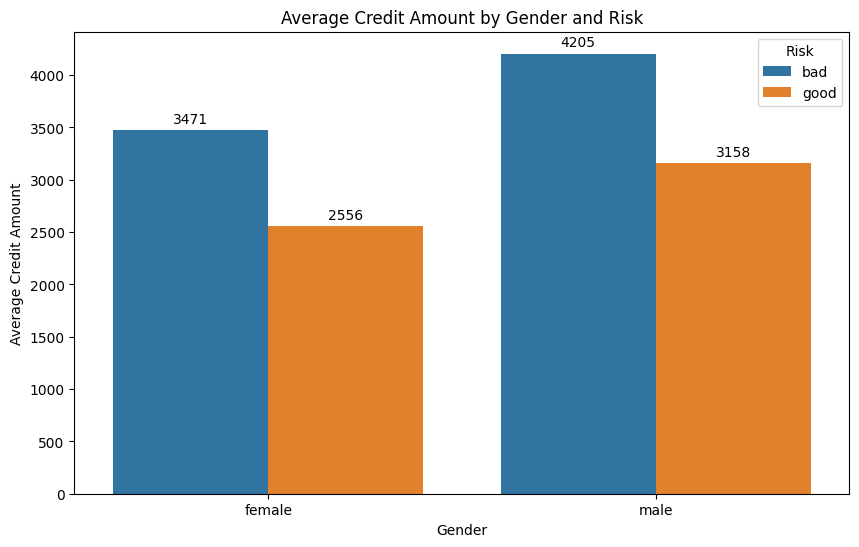

In [35]:
Sex_Credit = (
    df.groupby(['Sex', 'Risk'])['Credit amount']
      .mean()
      .reset_index()
)
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Sex_Credit,
    x='Sex',
    y='Credit amount',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.xlabel('Gender')
plt.ylabel('Average Credit Amount')
plt.title('Average Credit Amount by Gender and Risk')
plt.show()


## 📌 Observation

It is observed that **female customers** have a higher percentage of **bad credit risk (35.2%)** compared to **male customers (27.7%)**. To investigate whether this difference is associated with loan size, the average credit amount was analyzed for both genders.

---

## 💼 Business Insight

The analysis shows that **male customers classified as bad credit risk receive a higher average credit amount (4,205)** than **female customers (3,471)**. This indicates that the higher bad credit risk among female customers **cannot be explained solely by larger loan amounts**. Therefore, other factors such as loan duration, employment category, savings, checking account status, or additional financial characteristics may have a greater influence on the observed difference in credit risk.

---

## ✅ Recommendation

Banks should avoid assuming that higher loan amounts are the primary reason for increased credit risk among female customers. Instead, lending decisions should be based on a comprehensive evaluation of multiple customer attributes, including repayment history, financial stability, account balances, employment profile, and loan characteristics.

In [36]:
df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Age Group
0,67,male,2,own,little,little,1169,6,radio/TV,good,60+
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,18-30
2,49,male,1,own,little,little,2096,12,education,good,41-50
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,41-50
4,53,male,2,free,little,little,4870,24,car,bad,51-60


In [38]:
df['Purpose'].unique()

array(['radio/TV', 'education', 'furniture/equipment', 'car', 'business',
       'domestic appliances', 'repairs', 'vacation/others'], dtype=object)

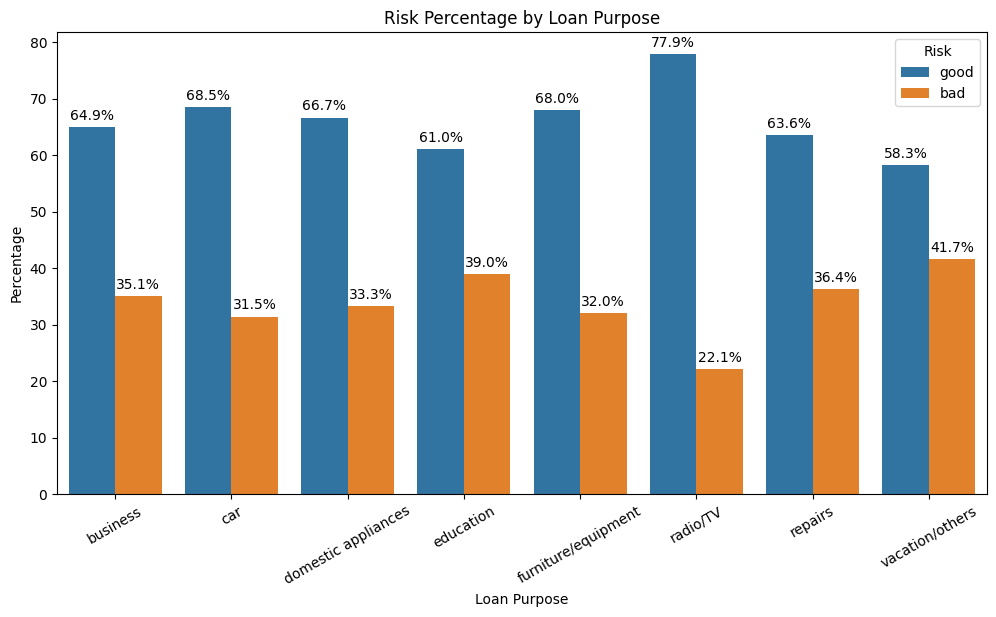

In [39]:
Purpose_Risk = (
    df.groupby('Purpose')['Risk']
      .value_counts(normalize=True)
      .rename('Percentage')
      .mul(100)
      .reset_index()
)
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=Purpose_Risk,
    x='Purpose',
    y='Percentage',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=30)
plt.xlabel('Loan Purpose')
plt.ylabel('Percentage')
plt.title('Risk Percentage by Loan Purpose')
plt.show()

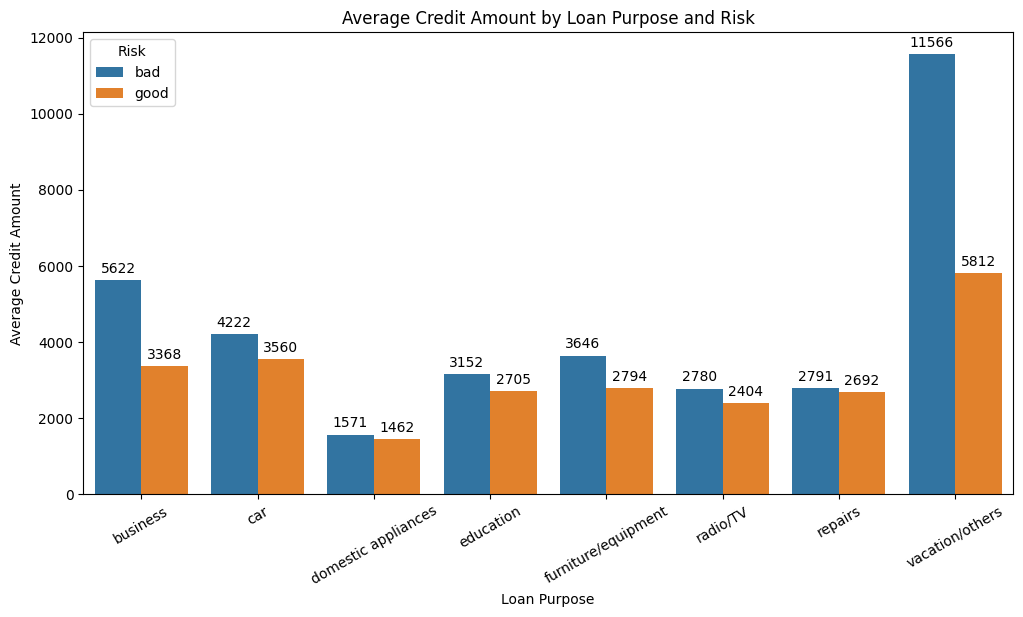

In [40]:
Purpose_Amount = (
    df.groupby(['Purpose','Risk'])['Credit amount']
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=Purpose_Amount,
    x='Purpose',
    y='Credit amount',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.xticks(rotation=30)
plt.xlabel('Loan Purpose')
plt.ylabel('Average Credit Amount')
plt.title('Average Credit Amount by Loan Purpose and Risk')
plt.show()

## 📌 Observation

It is observed that customers taking loans for **Vacation/Others** have the **highest percentage of bad credit risk (41.7%)**, followed by **Education (39.0%)** and **Repairs (36.4%)**. In contrast, customers borrowing for **Radio/TV** purchases have the **lowest bad credit risk (22.1%)** among all loan purposes.

To better understand this pattern, the average credit amount was analyzed across different loan purposes.

---

## 💼 Business Insight

The supporting analysis reveals that customers borrowing for **Vacation/Others** have the **highest average credit amount**, with bad credit risk customers receiving an average loan of approximately **11,566**, which is substantially higher than all other loan categories.

This suggests that the higher bad credit risk associated with **Vacation/Others** loans may be partially influenced by the larger loan amounts requested. Larger loans typically increase the financial burden on borrowers, making repayment more challenging and increasing the likelihood of credit default.

---

## ✅ Recommendation

Banks should apply stricter credit assessments for applicants requesting loans under the **Vacation/Others** category, particularly for high-value loan applications. Additional evaluation of repayment capacity, income stability, existing financial obligations, and previous credit history can help reduce the risk of loan defaults while maintaining responsible lending practices.

In [41]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Age Group
0,67,male,2,own,little,little,1169,6,radio/TV,good,60+
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,18-30
2,49,male,1,own,little,little,2096,12,education,good,41-50
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,41-50
4,53,male,2,free,little,little,4870,24,car,bad,51-60


In [42]:
df['Credit Amount Group'] = pd.cut(
    df['Credit amount'],
    bins=[0, 2000, 4000, 6000, 8000, df['Credit amount'].max()],
    labels=['0-2K', '2K-4K', '4K-6K', '6K-8K', '8K+']
)

In [44]:
Credit_Risk = (
    df.groupby('Credit Amount Group')['Risk']
      .value_counts(normalize=True)
      .rename('Percentage')
      .mul(100)
      .reset_index()
)

/tmp/ipykernel_1296/3753456258.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Credit Amount Group')['Risk']


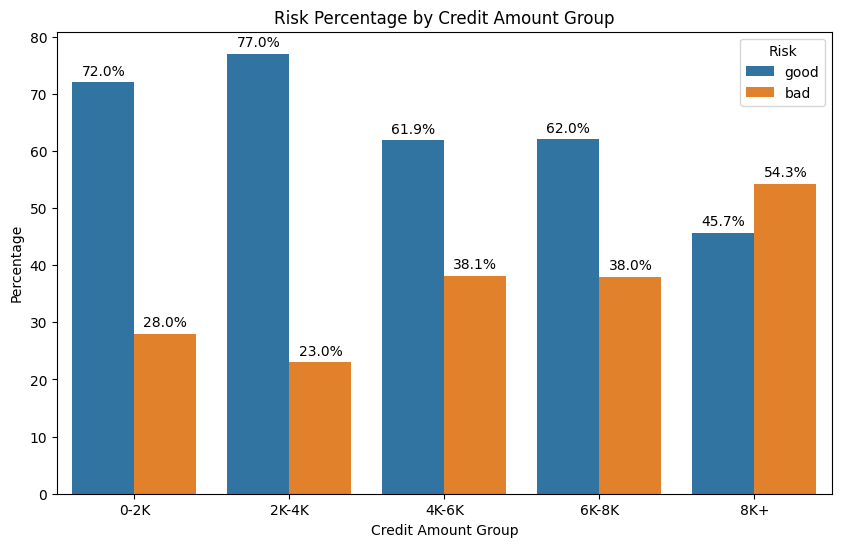

In [45]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Credit_Risk,
    x='Credit Amount Group',
    y='Percentage',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlabel('Credit Amount Group')
plt.ylabel('Percentage')
plt.title('Risk Percentage by Credit Amount Group')
plt.show()

/tmp/ipykernel_1296/1542218317.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Credit Amount Group','Risk'])['Duration']


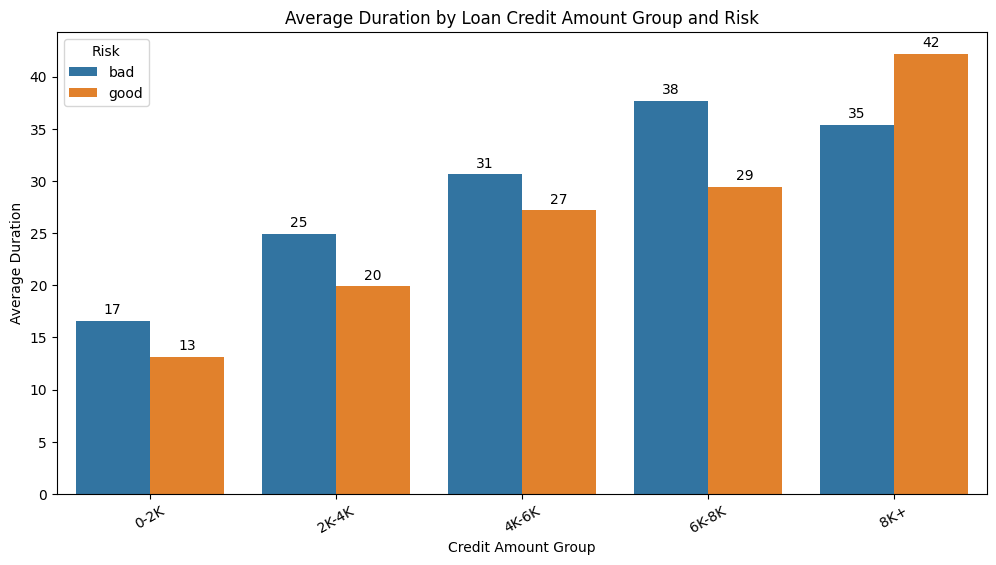

In [46]:
Amount_Duration = (
    df.groupby(['Credit Amount Group','Risk'])['Duration']
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=Amount_Duration,
    x='Credit Amount Group',
    y='Duration',
    hue='Risk'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.xticks(rotation=30)
plt.xlabel('Credit Amount Group')
plt.ylabel('Average Duration')
plt.title('Average Duration by Loan Credit Amount Group and Risk')
plt.show()

## 📌 Observation

It is observed that customers requesting loans of **8K+** have the **highest percentage of bad credit risk (54.3%)**, while customers borrowing between **2K–4K** have the **lowest bad credit risk (23.0%)**. The analysis indicates that the proportion of bad credit risk generally increases as the loan amount becomes larger.

To better understand this relationship, the average loan duration was analyzed across different credit amount groups.

---

## 💼 Business Insight

The supporting analysis shows that customers requesting **higher credit amounts** are also associated with **longer repayment durations**. For example, loans in the **8K+** category have an average repayment duration of approximately **35 months** for bad credit risk customers and **42 months** for good credit risk customers, which is considerably longer than lower-value loans.

This suggests that **larger loan amounts combined with longer repayment periods** may increase the financial burden on borrowers, thereby contributing to a higher likelihood of bad credit risk.

---

## ✅ Recommendation

Banks should apply enhanced credit risk assessments for customers requesting **high-value loans**, particularly those requiring longer repayment periods. Factors such as income stability, debt-to-income ratio, repayment history, and collateral should be carefully evaluated before approving large loans to minimize the risk of loan defaults.

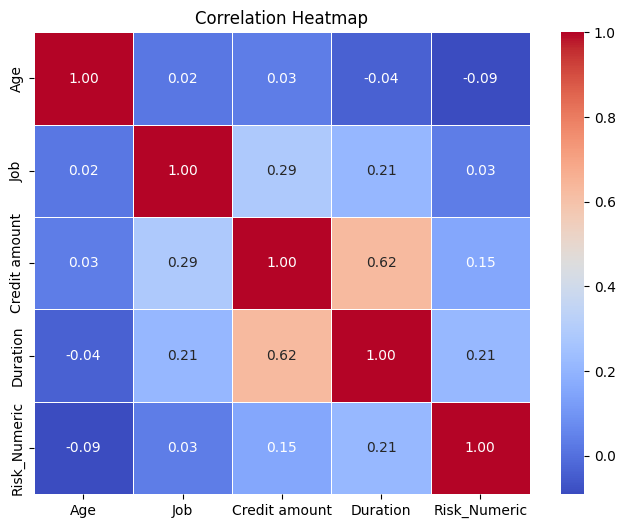

In [47]:
df['Risk_Numeric'] = df['Risk'].map({'good': 0, 'bad': 1})
corr = df[['Age',
           'Job',
           'Credit amount',
           'Duration',
           'Risk_Numeric']].corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

## 📌 Observation

A correlation heatmap was generated to examine the relationships between the numerical variables in the dataset. The strongest positive correlation was observed between **Credit Amount** and **Loan Duration (0.62)**, indicating that customers requesting larger loans generally choose longer repayment periods.

The **Risk** variable shows a **weak positive correlation** with **Loan Duration (0.21)** and **Credit Amount (0.15)**, while **Age (-0.09)** and **Job (0.03)** exhibit very weak relationships with credit risk.

---

## 💼 Business Insight

The correlation analysis suggests that **financial characteristics have a greater influence on credit risk than demographic characteristics**. Customers requesting **larger loans** with **longer repayment durations** are relatively more likely to be associated with bad credit risk. On the other hand, factors such as **Age** and **Job** show only weak linear relationships with credit risk, indicating that they should not be used as primary indicators when evaluating loan applications.

The strong relationship between **Credit Amount** and **Loan Duration** also supports the earlier finding that high-value loans are typically accompanied by longer repayment periods, which may increase the overall financial burden on borrowers.

---

## ✅ Recommendation

Banks should prioritize **loan amount** and **repayment duration** during the credit evaluation process, as these financial factors are more closely associated with credit risk than demographic attributes. Credit assessment models should combine these variables with account-related information and repayment history to improve lending decisions and reduce the likelihood of loan defaults.

📋 Executive Summary

The objective of this project was to perform Exploratory Data Analysis (EDA) on the German Credit Risk dataset to identify the key factors associated with customer credit risk and generate actionable business insights for financial institutions. The analysis explored customer demographics, financial characteristics, account information, loan attributes, and repayment behavior through univariate, bivariate, and multivariate analyses. The findings indicate that loan purpose, credit amount, repayment duration, and checking account status are more strongly associated with credit risk than demographic factors such as age, gender, and job category. These insights can help banks strengthen their credit assessment process, minimize loan defaults, and improve lending decisions.



📊 Key Findings
Customers aged 18–30 exhibited the highest proportion of bad credit risk, although this pattern could not be explained solely by loan amount or repayment duration.
Customers with moderate checking account balances showed the highest percentage of bad credit risk, while customers with rich checking accounts had the lowest.
Female customers demonstrated a higher percentage of bad credit risk than male customers; however, this difference was not explained by larger loan amounts, suggesting that additional financial factors contribute to the observed pattern.
Loans taken for Vacation/Others recorded the highest bad credit risk (41.7%) and were also associated with the highest average credit amount, indicating that larger discretionary loans may carry greater repayment risk.
Customers requesting loans above 8K showed the highest proportion of bad credit risk (54.3%). Supporting analysis revealed that these loans also had longer repayment durations, increasing the financial burden on borrowers.
The correlation analysis showed a strong positive relationship between Credit Amount and Loan Duration (0.62), while Loan Duration (0.21) and Credit Amount (0.15) exhibited positive relationships with credit risk. Demographic variables such as Age (-0.09) and Job (0.03) showed comparatively weak relationships with credit risk.

💼 Business Recommendations
Strengthen credit assessments for high-value loan applications, particularly those exceeding 8K, by carefully evaluating repayment capacity and financial stability.
Apply additional verification procedures for customers requesting Vacation/Others loans, as these loans are associated with both higher loan amounts and higher credit risk.
Consider checking account status as an important financial indicator during the loan approval process, while combining it with other financial variables rather than relying on it independently.
Avoid making lending decisions based solely on demographic characteristics such as age or gender. Instead, incorporate multiple financial indicators including loan amount, repayment duration, savings, checking account information, and previous repayment history.
Develop comprehensive credit scoring models that integrate customer financial behavior, loan characteristics, and account information to improve credit risk prediction and reduce default rates.

✅ Conclusion

This Exploratory Data Analysis successfully identified several important factors associated with customer credit risk in the German Credit Risk dataset. The analysis revealed that financial characteristics, including loan amount, loan purpose, repayment duration, and checking account status, have a greater influence on credit risk than demographic attributes alone. By adopting data-driven lending strategies and considering multiple financial indicators during credit evaluation, banks can make more informed loan approval decisions, reduce the likelihood of loan defaults, and improve overall portfolio quality.